In [1]:
import glob
import warnings
import numpy as np
import pandas as pd
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import cartopy.crs as ccrs
import cartopy.feature as cfeature

from traffic.core import Traffic, Flight
from traffic.data import airports

import re
from datetime import timedelta, date
import polars as pl

warnings.filterwarnings('ignore')
print("Imports OK")

Imports OK


--- 
### 1. CHARGEMENT ET PRÉPARATION DES DONNÉES

In [ ]:
print("Chargement des fichiers Parquet...")
df_cdg = pd.read_parquet('trajectoires_TLS_CDG.parquet')
df_ory = pd.read_parquet('trajectoires_TLS_ORY.parquet')
t_cdg = Traffic(df_cdg)
t_ory = Traffic(df_ory)

print(f"Nombre de points chargés - CDG: {len(df_cdg)}, ORY: {len(df_ory)}")
print(f"Nombre de trajectoires uniques - CDG: {len(t_cdg)}, ORY: {len(t_ory)}")

Chargement des fichiers Parquet...
Nombre de points chargés - CDG: 52393, ORY: 79455
Nombre de trajectoires uniques - CDG: 131, ORY: 218


--- 
### 2. VISUALISATION DES COULOIRS DE TRAJECTOIRES

Génération du graphique cartographique...


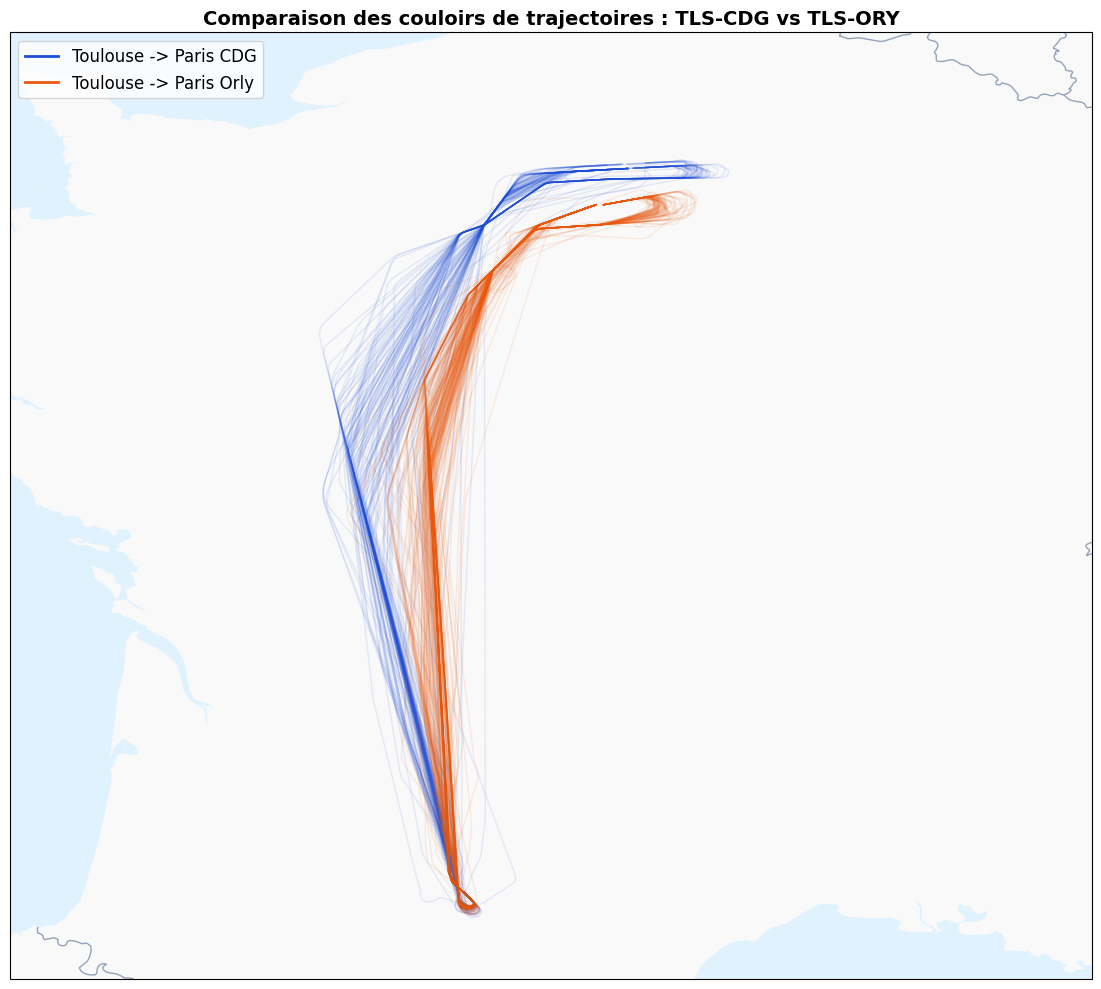

In [ ]:
print("Génération du graphique cartographique...")
projection = ccrs.PlateCarree()
fig, ax = plt.subplots(figsize=(12, 10), subplot_kw=dict(projection=projection))

ax.add_feature(cfeature.LAND, facecolor='#f9f9f9')
ax.add_feature(cfeature.OCEAN, facecolor='#e0f2fe')
ax.add_feature(cfeature.BORDERS, edgecolor='#94a3b8', linewidth=1)

t_cdg.plot(ax, color='#1d4ed8', alpha=0.1, label='TLS -> CDG')
t_ory.plot(ax, color='#ea580c', alpha=0.1, label='TLS -> ORY')
ax.set_extent([-2, 6, 43, 50], crs=projection)

from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color='#1d4ed8', lw=2, label='Toulouse -> Paris CDG'),
    Line2D([0], [0], color='#ea580c', lw=2, label='Toulouse -> Paris Orly')
]
ax.legend(handles=legend_elements, loc='upper left', fontsize=12)
ax.set_title("Comparaison des couloirs de trajectoires : TLS-CDG vs TLS-ORY", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

--- 
### 3. CALCUL DES MÉTRIQUES

In [ ]:
def compute_traffic_metrics(t_object):
    metrics = []
    for flight in t_object:
        total_distance = flight.distance() 
        duration = flight.stop - flight.start
        duration_minutes = duration.total_seconds() / 60.0
        max_alt = flight.data['altitude'].max() if 'altitude' in flight.data.columns else flight.data['geoaltitude'].max()
        max_gs = flight.data['velocity'].max() if 'velocity' in flight.data.columns else None
        
        metrics.append({
            'callsign': flight.callsign,
            'distance_nm': total_distance,
            'duration_min': duration_minutes,
            'max_altitude': max_alt,
            'max_groundspeed': max_gs
        })
    return pd.DataFrame(metrics)

df_metrics_cdg = compute_traffic_metrics(t_cdg)
df_metrics_ory = compute_traffic_metrics(t_ory)
summary_cdg = df_metrics_cdg.describe().loc[['mean', 'std', 'min', 'max']]
summary_ory = df_metrics_ory.describe().loc[['mean', 'std', 'min', 'max']]

print("\n=== Statistiques Moyennes pour TLS -> CDG ===")
print(summary_cdg.to_string())
print("\n=== Statistiques Moyennes pour TLS -> ORY ===")
print(summary_ory.to_string())


--- Calcul des métriques statistiques ---

=== Statistiques Moyennes pour TLS -> CDG ===
      distance_nm  duration_min   max_altitude
mean   326.149269     66.687023   34058.207197
std      1.315661      9.579426   13331.093868
min    321.230169     53.833333   17050.000546
max    330.091775    109.166667  120600.003859

=== Statistiques Moyennes pour TLS -> ORY ===
      distance_nm  duration_min  max_altitude
mean   308.542034     60.774465  32253.556078
std      0.780834      5.955843   3205.389875
min    298.641921     48.000000  18000.000576
max    310.597744     85.666667  44700.001430
